# Task 1: Load the dataset into a DataFrame

In [96]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [97]:
df = pd.read_csv('Ecommerce Customers.csv')

# Task 2: Explore the data (head, info, describe)

In [98]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [99]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


# Task 3: Perform basic data cleaning

In [101]:
df.isna().sum()
df=df.drop(columns=['Email', 'Address'])

No missing values, great for Linear regression. And the unesseary columns were dropped. 

In [102]:
df['Avatar'].unique().size

138

In [103]:
#138 is a lot of unique categories, so I will use K-value encoding
K = 10 
top_k = df['Avatar'].value_counts().nlargest(K).index

df['Avatar_topk'] = df['Avatar'].where(df['Avatar'].isin(top_k), 'Other')
df = pd.get_dummies(df, columns=['Avatar_topk'], drop_first=True)
df.columns


Index(['Avatar', 'Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent', 'Avatar_topk_Cyan',
       'Avatar_topk_DarkViolet', 'Avatar_topk_DeepPink',
       'Avatar_topk_GreenYellow', 'Avatar_topk_LightSkyBlue',
       'Avatar_topk_Other', 'Avatar_topk_Purple', 'Avatar_topk_SlateBlue',
       'Avatar_topk_Teal', 'Avatar_topk_Turquoise'],
      dtype='object')

In [104]:
df = df.loc[:, ~df.columns.duplicated()]
topk_cols = df.filter(like='Avatar_topk_').columns
df[topk_cols] = df[topk_cols].astype(int)

In [107]:
df = df.drop(columns=['Avatar'])
df.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,Avatar_topk_Cyan,Avatar_topk_DarkViolet,Avatar_topk_DeepPink,Avatar_topk_GreenYellow,Avatar_topk_LightSkyBlue,Avatar_topk_Other,Avatar_topk_Purple,Avatar_topk_SlateBlue,Avatar_topk_Teal,Avatar_topk_Turquoise
0,34.497268,12.655651,39.577668,4.082621,587.951054,0,0,0,0,0,1,0,0,0,0
1,31.926272,11.109461,37.268959,2.664034,392.204933,0,0,0,0,0,1,0,0,0,0
2,33.000915,11.330278,37.110597,4.104543,487.547505,0,0,0,0,0,1,0,0,0,0
3,34.305557,13.717514,36.721283,3.120179,581.852344,0,0,0,0,0,1,0,0,0,0
4,33.330673,12.795189,37.536653,4.446308,599.406092,0,0,0,0,0,1,0,0,0,0


In [108]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df))

In [109]:
df['Avg. Session Length'] = np.log1p(df['Avg. Session Length'])
df['Time on App'] = np.log1p(df['Time on App'])
df['Time on Website'] = np.log1p(df['Time on Website'])
df['Length of Membership'] = np.log1p(df['Length of Membership'])
df['Yearly Amount Spent'] = np.log1p(df['Yearly Amount Spent'])

Detected and handled outliers using "Log transform skewed variables"

In [110]:
df = df.drop_duplicates()

Handled duplicated data entries.

# Task 4: Apply feature engineering (if applicable) 

Most data in this dataset are stand-alone values, so we are going to use them on their own.

# Task 5: Prepare the data for modeling

In [111]:
df.head() #To take a look at the dataset after feature engineering and cleaning. 

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,Avatar_topk_Cyan,Avatar_topk_DarkViolet,Avatar_topk_DeepPink,Avatar_topk_GreenYellow,Avatar_topk_LightSkyBlue,Avatar_topk_Other,Avatar_topk_Purple,Avatar_topk_SlateBlue,Avatar_topk_Teal,Avatar_topk_Turquoise
0,3.569456,2.614153,3.703218,1.625827,6.378343,0,0,0,0,0,1,0,0,0,0
1,3.494271,2.493987,3.644639,1.298565,5.974331,0,0,0,0,0,1,0,0,0,0
2,3.526387,2.512058,3.640492,1.630131,6.191437,0,0,0,0,0,1,0,0,0,0
3,3.564040,2.689038,3.630224,1.415897,6.367934,0,0,0,0,0,1,0,0,0,0
4,3.536039,2.624320,3.651610,1.694938,6.397606,0,0,0,0,0,1,0,0,0,0


In [112]:
#Features:
X = df[['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership', 'Avatar_topk_Cyan',
       'Avatar_topk_DarkViolet', 'Avatar_topk_DeepPink',
       'Avatar_topk_GreenYellow', 'Avatar_topk_LightSkyBlue',
       'Avatar_topk_Other', 'Avatar_topk_Purple', 'Avatar_topk_SlateBlue',
       'Avatar_topk_Teal', 'Avatar_topk_Turquoise']]
#Target Variable: 
y= df['Yearly Amount Spent']

In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, 
                                                    random_state= 42)

# Task 6: Train the model

In [114]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

lm.fit(X_train, y_train)

LinearRegression()

# Task 7: Evaluate the model performance

In [115]:
print(lm.intercept_)

-3.661522996380289


In [116]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns= ['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,1.784471
Time on App,1.019158
Time on Website,0.043301
Length of Membership,0.526868
Avatar_topk_Cyan,0.006731
Avatar_topk_DarkViolet,0.002875
Avatar_topk_DeepPink,0.026924
Avatar_topk_GreenYellow,0.022495
Avatar_topk_LightSkyBlue,0.034548
Avatar_topk_Other,0.015232


In [117]:
Predictions = lm.predict(X_test)

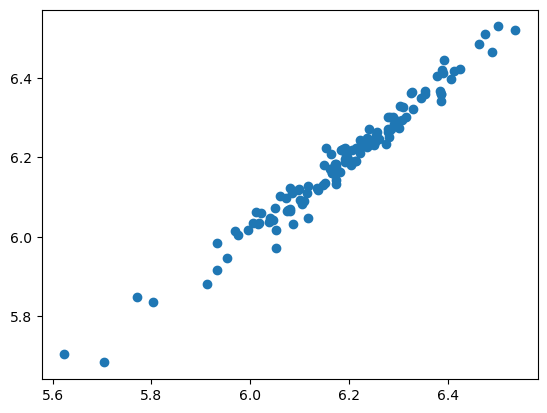

In [118]:
plt.scatter(y_test, Predictions)

The datapoins are almost in a straight line. Indicating good enough performance. 

C:\Users\Aleen\AppData\Local\Temp\ipykernel_26212\445099331.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-Predictions), bins= 50);


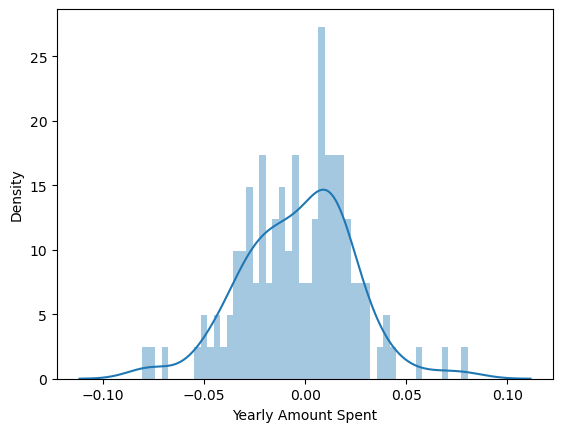

In [119]:
sns.distplot((y_test-Predictions), bins= 50);

In [120]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, Predictions))
print('MSE:', metrics.mean_squared_error(y_test, Predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, Predictions)))

MAE: 0.021458908391230318
MSE: 0.0007390307625968786
RMSE: 0.02718512024245761
